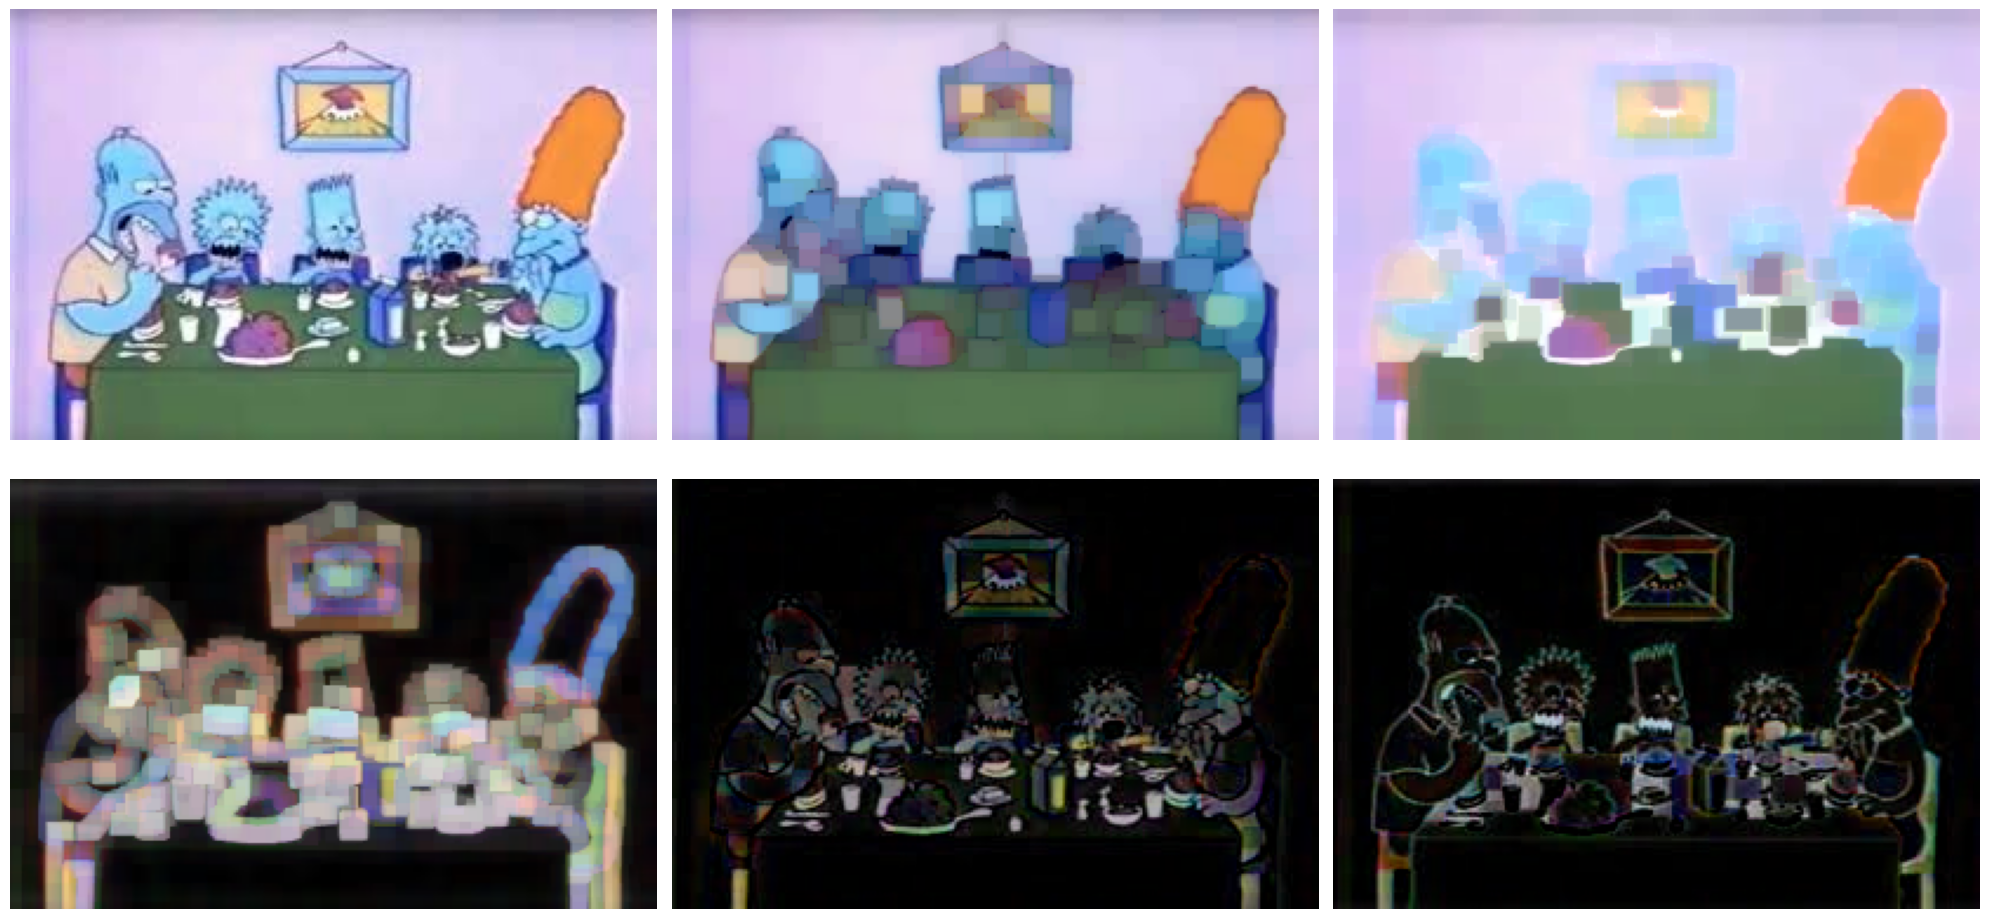

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Apply the operations
img = cv2.imread('simpson.jpg')
kernel = np.ones((9, 9), np.uint8)
img_open = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel) 
img_close = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
img_grad = cv2.morphologyEx(img, cv2.MORPH_GRADIENT,kernel)
img_tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
img_blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)

images = [img, img_open, img_close, img_grad, img_tophat, img_blackhat]

# Plot the images

plt.figure(figsize = (20, 10))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap = 'gray')
    plt.axis('off')
    
plt.tight_layout()
plt.show()

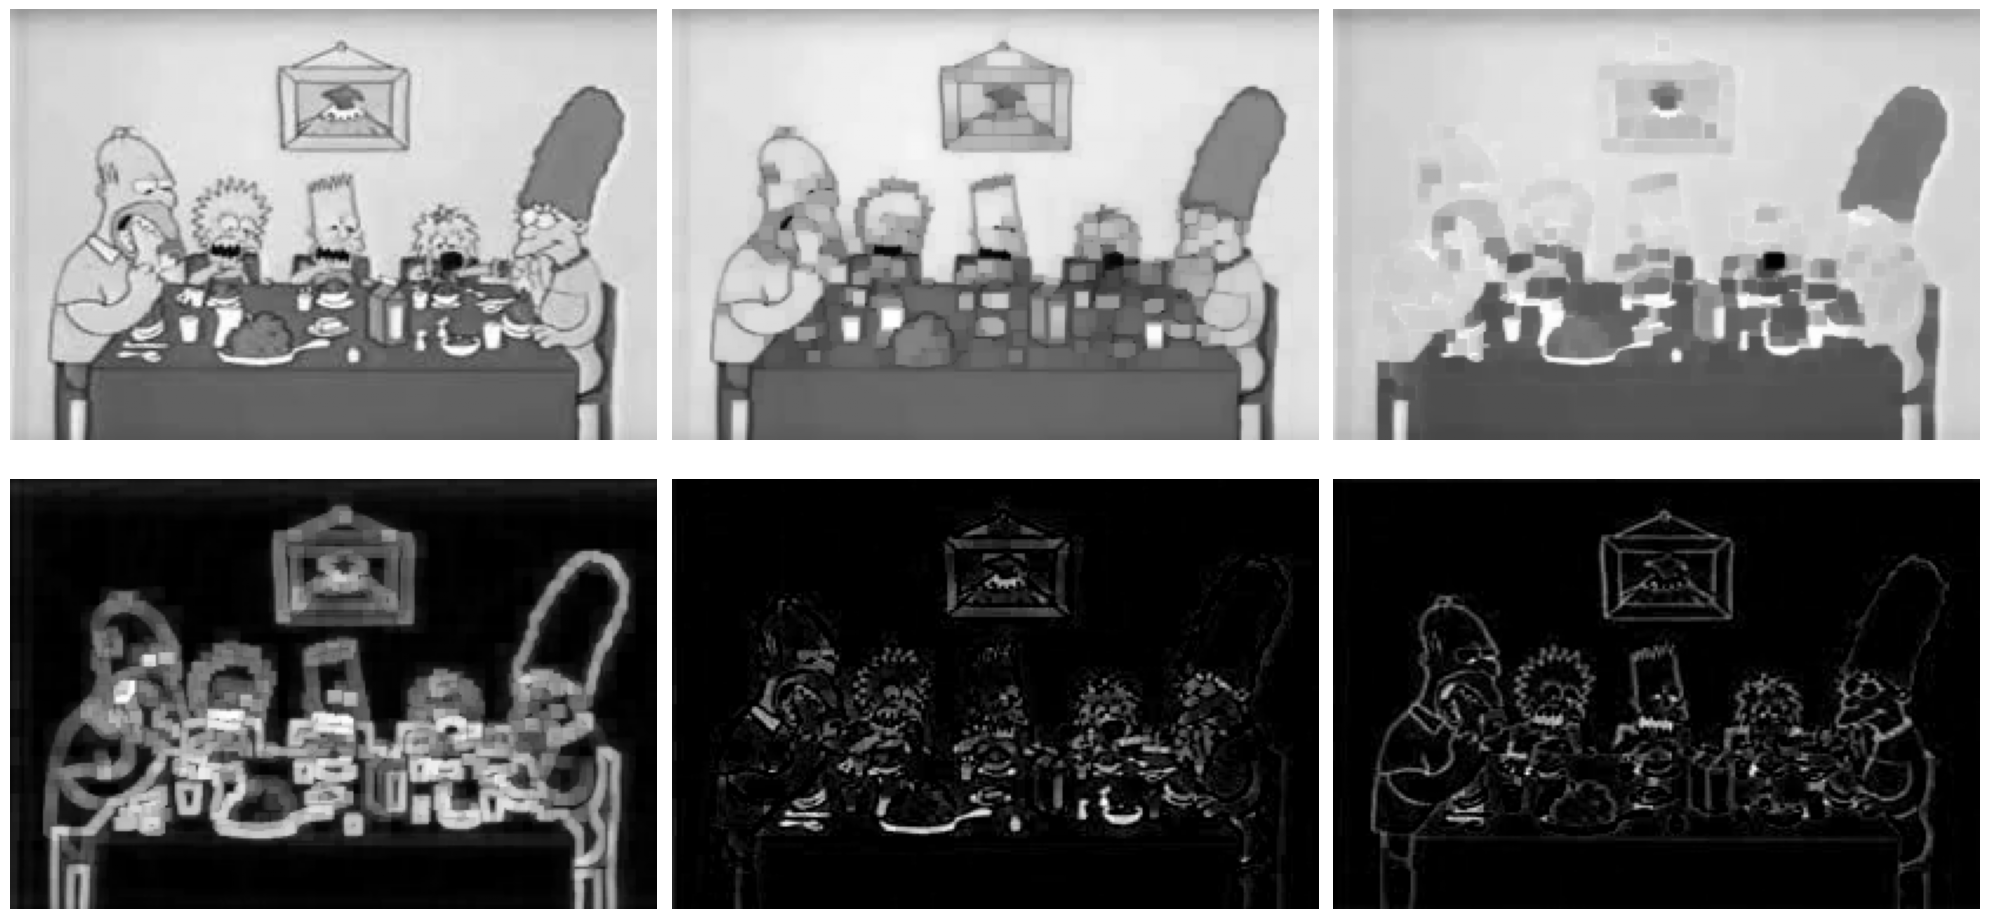

In [10]:
#試試看不同morpholotyEx模式與kernel大小的差別？
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
kernel = np.ones((5, 5), np.uint8)
img_open = cv2.morphologyEx(img_gray, cv2.MORPH_OPEN, kernel)
img_close = cv2.morphologyEx(img_gray, cv2.MORPH_CLOSE, kernel)
img_grad = cv2.morphologyEx(img_gray, cv2.MORPH_GRADIENT, kernel)
img_tophat = cv2.morphologyEx(img_gray, cv2.MORPH_TOPHAT, kernel)
img_blackhat = cv2.morphologyEx(img_gray, cv2.MORPH_BLACKHAT, kernel)

images = [img_gray, img_open, img_close, img_grad, img_tophat, img_blackhat]

# Plot the images

plt.figure(figsize = (20, 10))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap = 'gray')
    plt.axis('off')
    
plt.tight_layout()
plt.show()

dtype: uint8
shape: (298, 299)


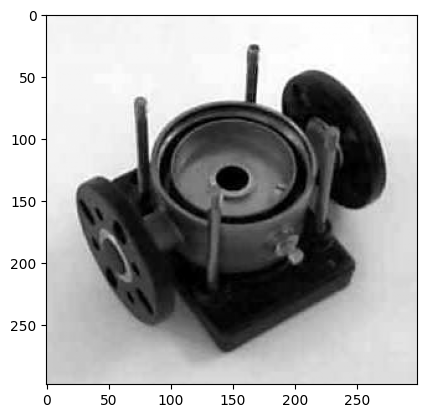

In [11]:
input_image = cv2.imread('wheel.png', cv2.IMREAD_GRAYSCALE)  
print('dtype: ' + str(input_image.dtype))
print('shape: ' + str(input_image.shape))

plt.imshow(input_image, cmap='gray') 

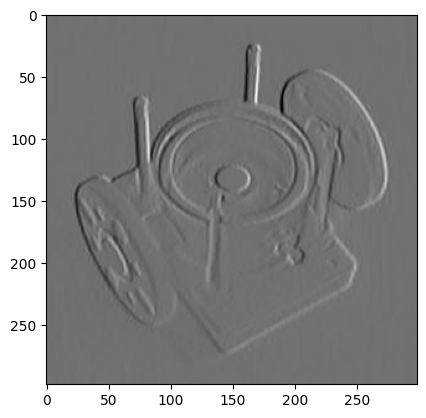

In [13]:
#如何使用sobel?
ddepth = cv2.CV_64F  # 64-bit float output 
dx =  1              # First-order derivative in x-direction 
dy =  0             # NO derivative in y-direction 
sobelx = cv2.Sobel(input_image, ddepth, dx, dy)

plt.imshow(sobelx, cmap='gray')

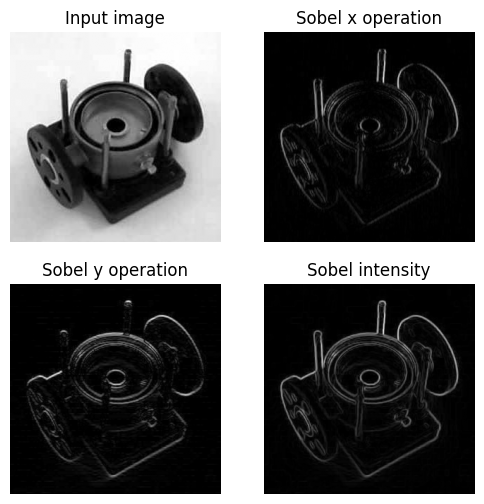

In [15]:
#如何同時使用x y方向的sobel?
sobelx = cv2.Sobel(input_image, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(input_image, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)

plt.figure(figsize=(6, 6));
plt.subplot(2, 2, 1); plt.title('Input image'); plt.axis('off');
plt.imshow(input_image, cmap='gray');
plt.subplot(2, 2, 2); plt.title('Sobel x operation'); plt.axis('off');
plt.imshow(cv2.absdiff(sobelx, 0.0), cmap='gray')
plt.subplot(2, 2, 3); plt.title('Sobel y operation'); plt.axis('off');
plt.imshow(cv2.absdiff(sobely, 0.0), cmap='gray');
plt.subplot(2, 2, 4); plt.title('Sobel intensity'); plt.axis('off');
plt.imshow(sobel, cmap='gray');

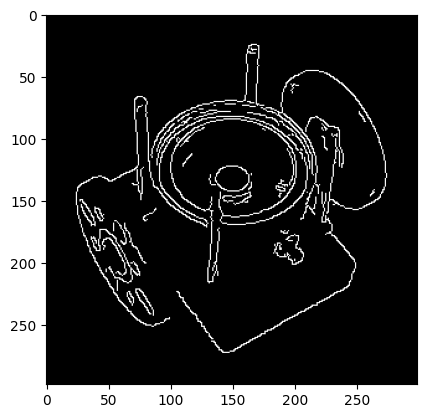

In [17]:
#如何使用canny?
threshold1 = 100
threshold2 = 200
canny = cv2.Canny(input_image, threshold1, threshold2)

plt.imshow(canny, cmap='gray')

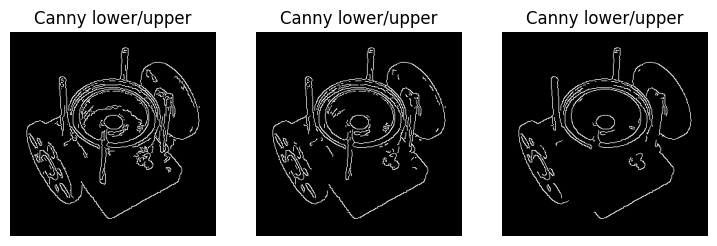

In [18]:
#試試不同threshold 對canny的效果？

canny1 = cv2.Canny(input_image, 50, 150)
canny2 = cv2.Canny(input_image, 100,150)
canny3 = cv2.Canny(input_image, 150, 250)

plt.figure(figsize=(9, 3));
plt.subplot(1, 3, 1); plt.title('Canny lower/upper'); plt.axis('off');
plt.imshow(canny1, cmap='gray');
plt.subplot(1, 3, 2); plt.title('Canny lower/upper'); plt.axis('off');
plt.imshow(canny2, cmap='gray');
plt.subplot(1, 3, 3); plt.title('Canny lower/upper'); plt.axis('off');
plt.imshow(canny3, cmap='gray');

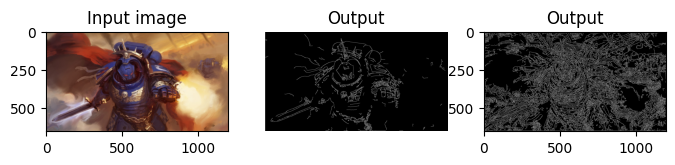

In [ ]:
#試試彩色影像與灰階影像用canny的差別？
image = cv2.imread('Warhammer40k.jpg', cv2.IMREAD_COLOR)

edges = cv2.Canny(image, 100, 200)
image_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

edges_gray = cv2.Canny(image_gray, 100, 200)
edges_l2 = cv2.Canny(image_gray, 100, 200, apertureSize=5, L2gradient=True)

plt.figure(figsize=(8, 3));
plt.subplot(1, 3, 1); plt.title('Input image'); plt.axis('on'); 
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB));

plt.subplot(1, 3, 2); plt.title('Output'); plt.axis('off');
plt.imshow(edges, cmap='gray');  

plt.subplot(1, 3, 3); plt.title('Output'); plt.axis('on');
plt.imshow(edges_gray, cmap='gray');  


(np.float64(-0.5), np.float64(1199.5), np.float64(655.5), np.float64(-0.5))

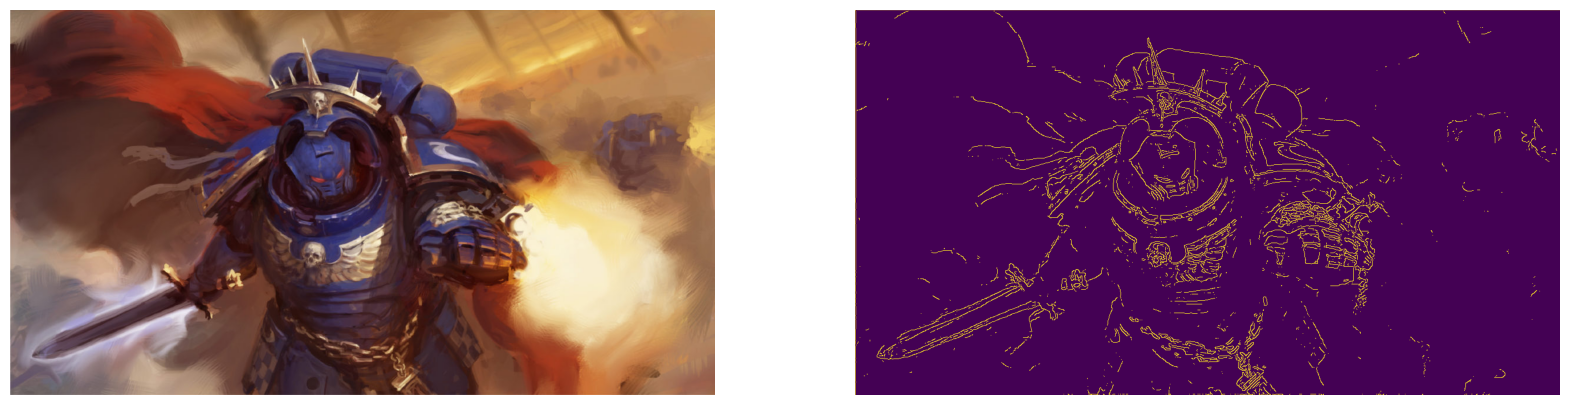

In [28]:
img = cv2.imread('Warhammer40k.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Canny 檢測 沒有 模糊
# Canny detection without blurring


edges = cv2.Canny(image=img, threshold1=125, threshold2=125)
plt.figure(figsize = (20, 20))
plt.subplot(1, 2, 1); plt.imshow(img)
plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(edges)
plt.axis('off')

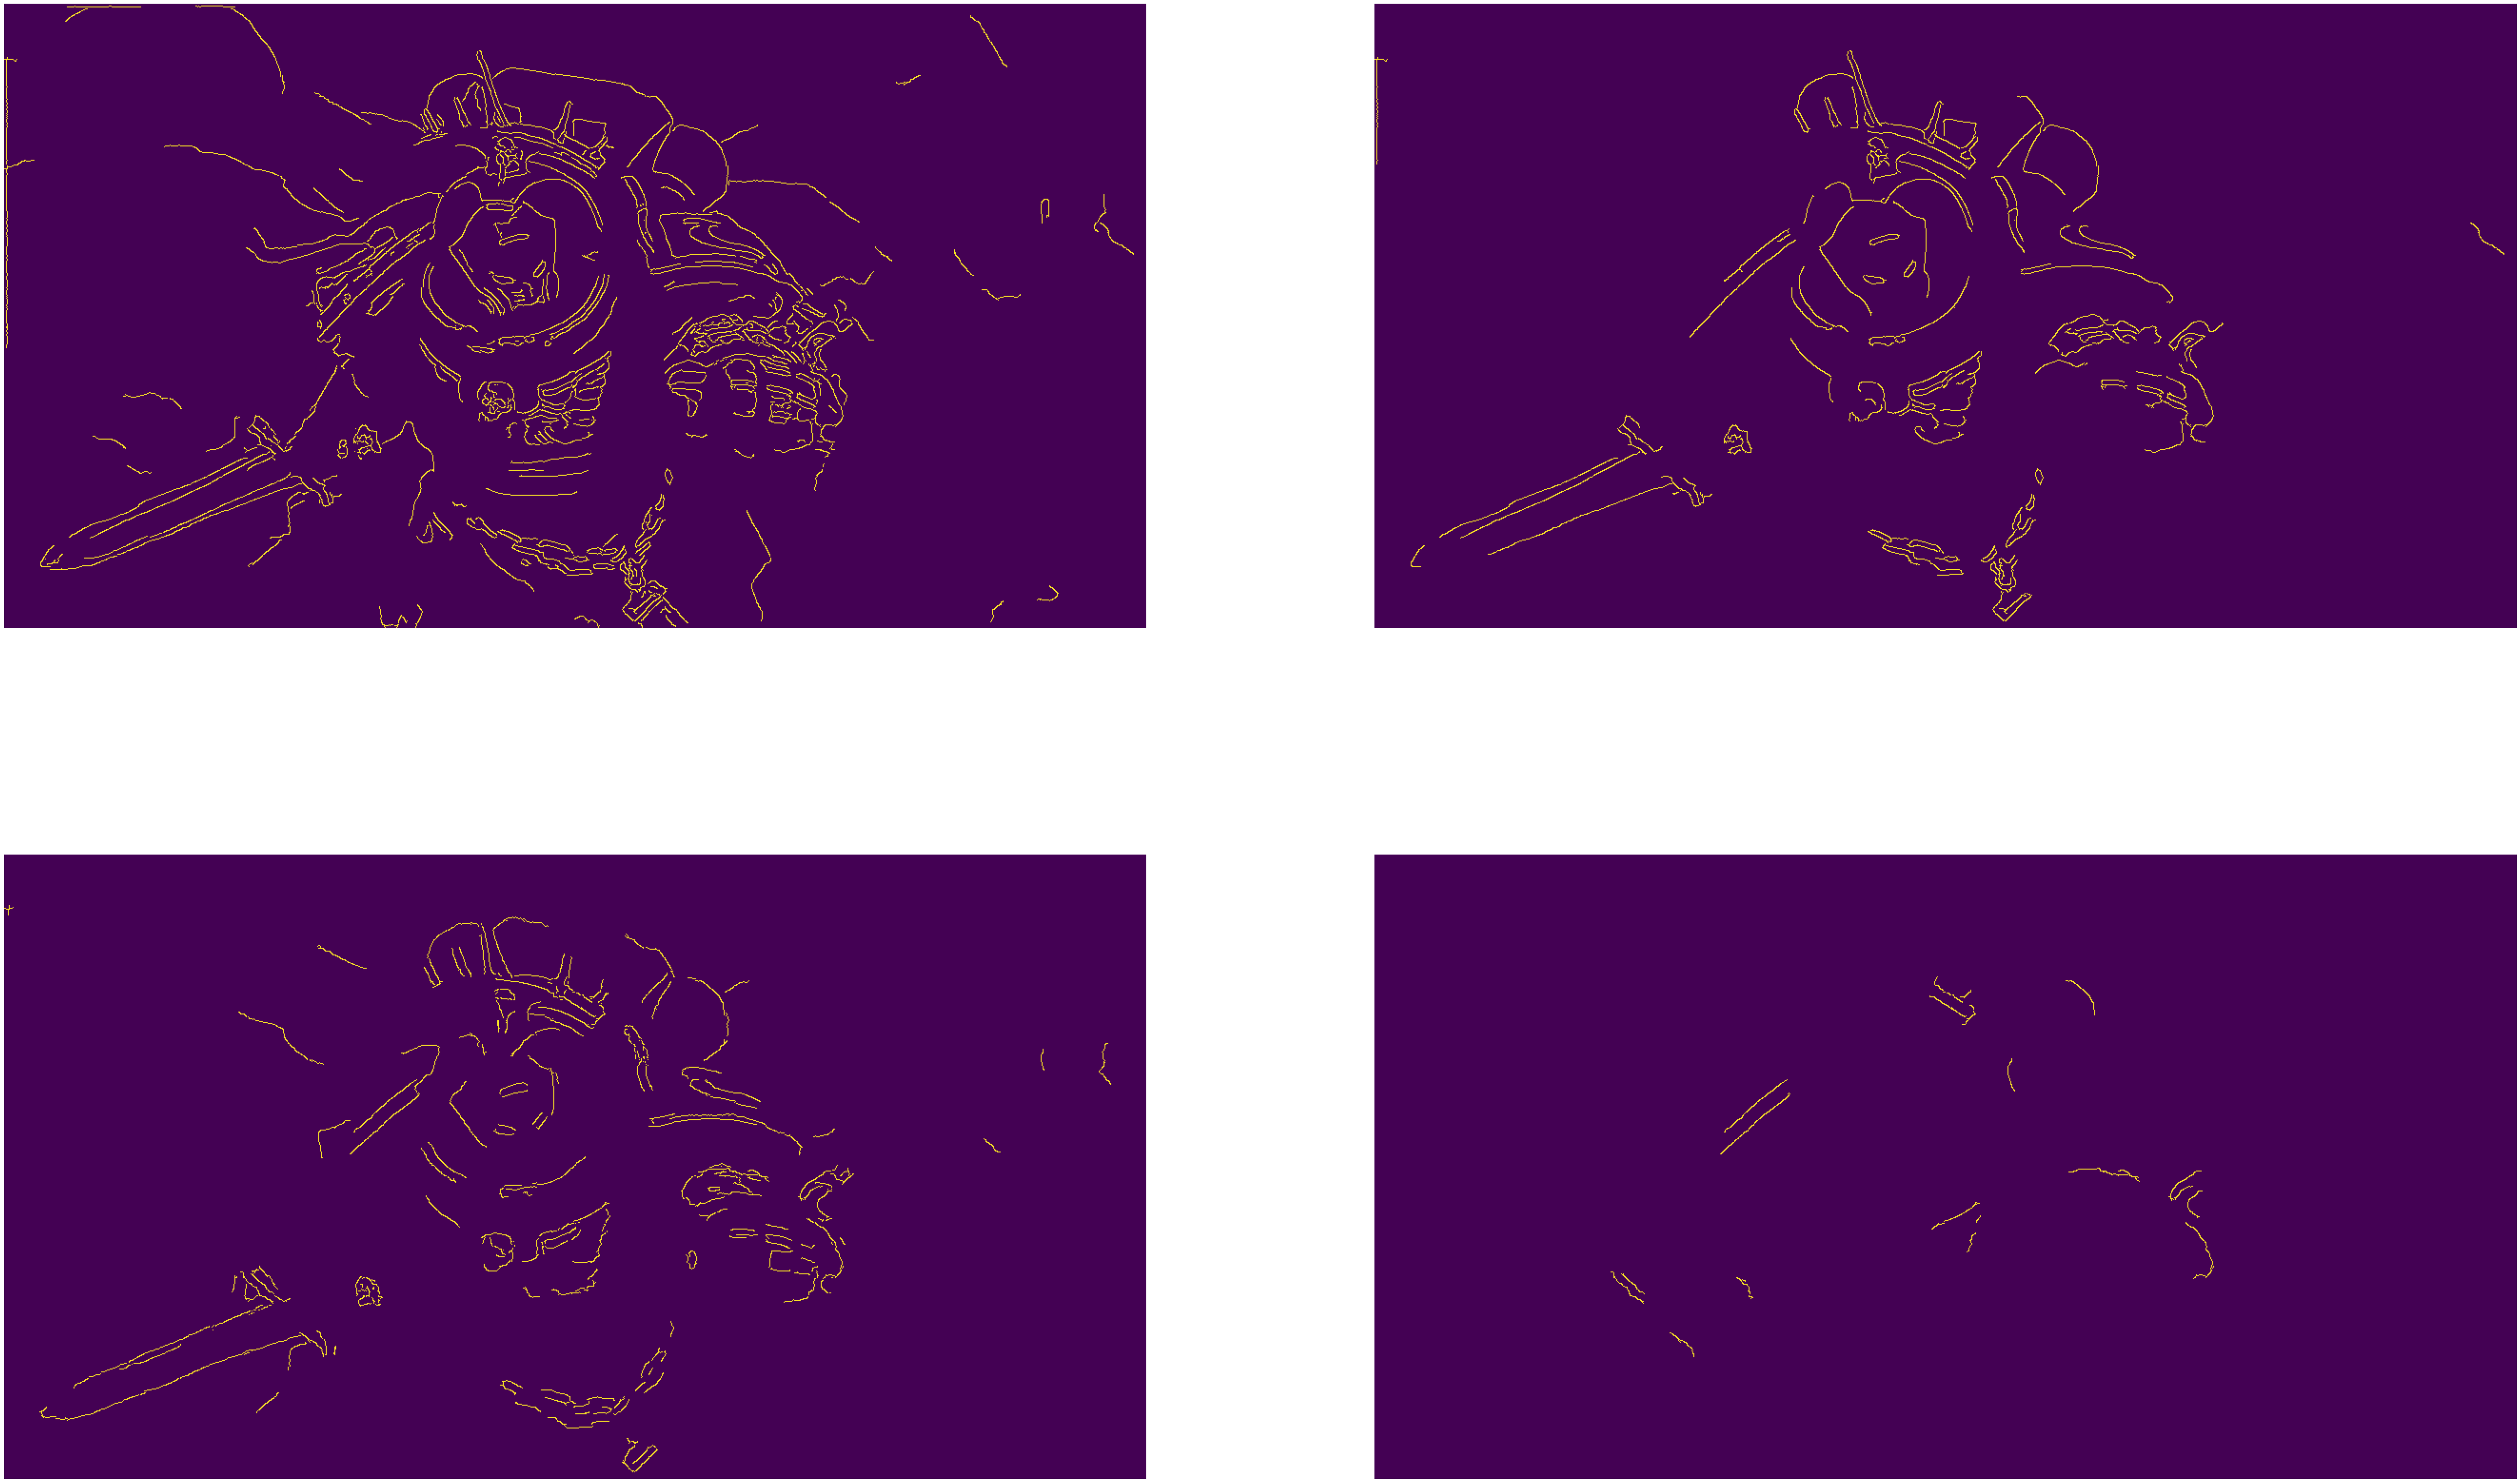

In [29]:
#如果canny前先去除雜訊呢？效果如何？
med_val = np.median(img)
lower = int(max(0, .7*med_val))
upper = int(min(255, 1.3*med_val))
# Blurring with ksize = 5
img_k5 = cv2.blur(img, ksize = (5, 5)) 
# Canny detection with different thresholds 
edges_k5 = cv2.Canny(img_k5, threshold1 = lower, threshold2 = upper)
edges_k5_2 = cv2.Canny(img_k5, lower, upper+100)
# Blurring with ksize = 9
img_k9 = cv2.blur(img, ksize=(9,9))
# Canny detection with different thresholds 
edges_k9 = cv2.Canny(img_k9, lower, upper)
edges_k9_2 = cv2.Canny(img_k9, lower, upper+100)
# Plot the images 
images = [edges_k5, edges_k5_2, edges_k9, edges_k9_2]
plt.figure(figsize = (80, 50))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(298.5), np.float64(167.5), np.float64(-0.5))

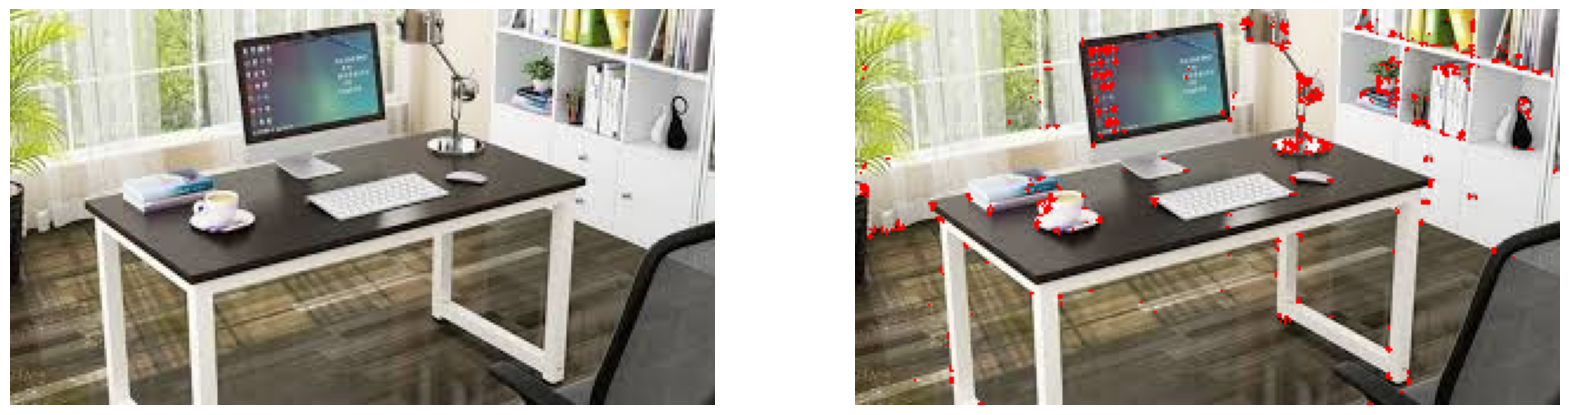

In [31]:
#嘗試使用Harris corner detection
img = cv2.imread('desk.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
dst = cv2.cornerHarris(img_gray, blockSize = 2, ksize = 3, k = .04) #Apply Harris corner detector
img_corner = img.copy()
img_corner[dst>0.01*dst.max()]=[255,0,0]#coloring the corner

plt.figure(figsize = (20, 20))
plt.subplot(1, 2, 1); plt.imshow(img)
plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(img_corner)
plt.axis('off')

(np.float64(-0.5), np.float64(298.5), np.float64(167.5), np.float64(-0.5))

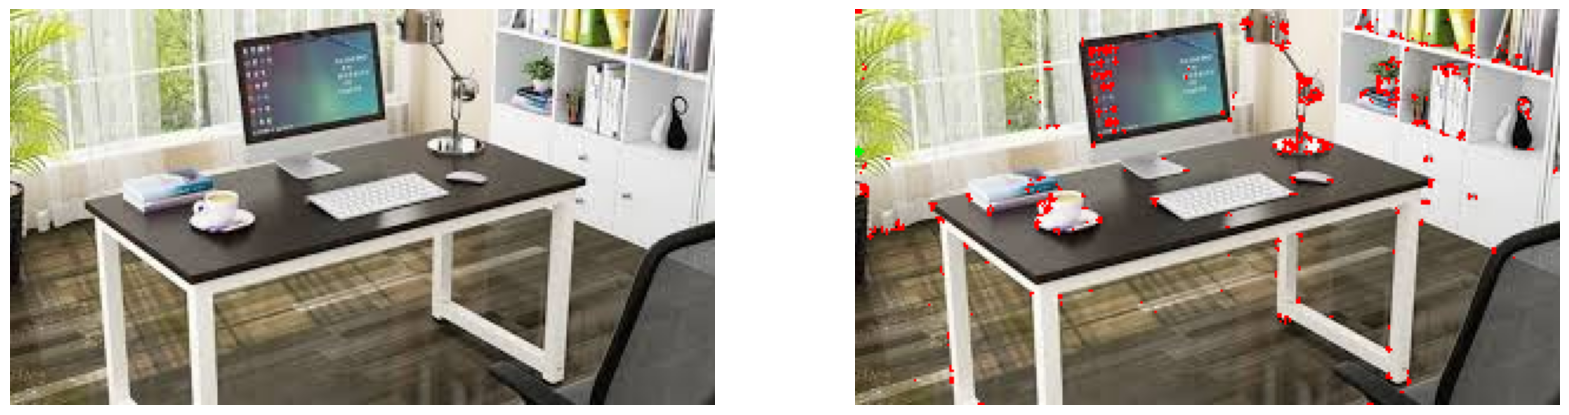

In [38]:
# 嘗試使用shi-tomasi corner detection 
corners = cv2.goodFeaturesToTrack(image_gray, maxCorners=100, qualityLevel=0.01, minDistance=10)
corners = np.intp(corners) #numpy.int0 or numpy.intp有何作用？ 

#  Spot the detected corners

img_croner = img.copy()
for i in corners:
    x,y = i.ravel()
    
    cv2.circle(img_corner, center = (x, y), 
               radius = 2, color = (0,255,0), thickness = -1)

# Plot  the image
plt.figure(figsize = (20, 20))
plt.subplot(1, 2, 1); plt.imshow(img)
plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(img_corner)
plt.axis('off')

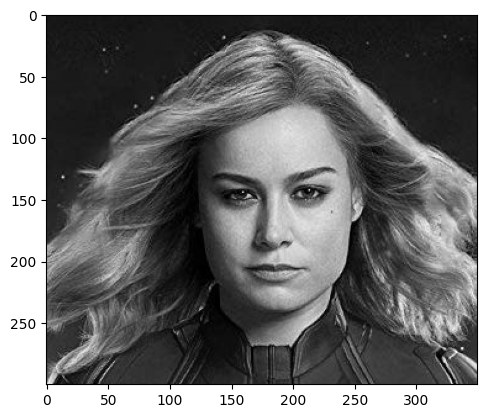

In [39]:
cap_mavl = cv2.imread('captin_marvel.jpg')
cap_mavl = cv2.cvtColor(cap_mavl, cv2.COLOR_BGR2RGB) 
len(cap_mavl[0:5])
#display(cap_mavl[0:5])
len(cap_mavl)
cap_mavl.shape
# Find the resion of interest
roi = cap_mavl[50:350, 200:550]
plt.imshow(roi)
# Convert the roi to grayscale
roi = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
plt.imshow(roi, cmap = 'gray')

Found 1 faces!


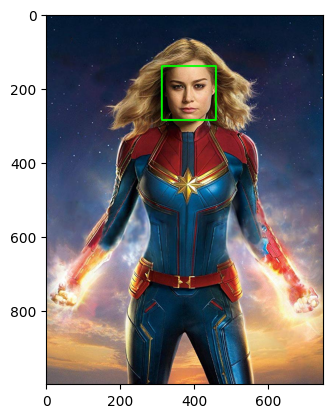

In [40]:

img = cv2.imread('captin_marvel.jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Create the haar cascade 
#cascPath = 'detect/haarcascade_frontalface_default.xml'
cascPath = 'haarcascades/haarcascade_frontalface_alt.xml'
faceCascade = cv2.CascadeClassifier(cascPath)

def detect_faces_show(fpath):
    img = cv2.imread(fpath)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 檢測圖像中 的面部
    # Detect faces in the image
    faces = faceCascade.detectMultiScale(
        img_rgb,
        scaleFactor=1.2,
        minNeighbors=5,
        minSize=(30, 30),
        flags = cv2.CASCADE_SCALE_IMAGE
    )
    print("Found %d faces!" % len(faces))

    # 臉部 周圍畫 一個矩形
    # Draw a rectangle around the faces
    
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 4)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
detect_faces_show('captin_marvel.jpg')

In [42]:
import cv2
import numpy as np

face_cascade = cv2.CascadeClassifier('haarcascades/haarcascade_frontalface_default.xml')

def detect_face(img):
    
    img_copy = img.copy()
    face_rects = face_cascade.detectMultiScale(img_copy)
    
    for (x, y, w, h) in face_rects:
        cv2.rectangle(img_copy, (x, y), (x+w, y+h), (0, 255, 0), 3)
        
    return img_copy


cap = cv2.VideoCapture(0) 

while True: 
    ret, frame = cap.read(1) 
    frame = detect_face(frame)
    cv2.imshow('Video Face Detection', frame) 
    c = cv2.waitKey(1) 
    if c == 27: #ESC
        break 
        
cap.release() 
cv2.destroyAllWindows()

2025-09-18 15:44:12.666 Python[18381:1725071] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


KeyboardInterrupt: 

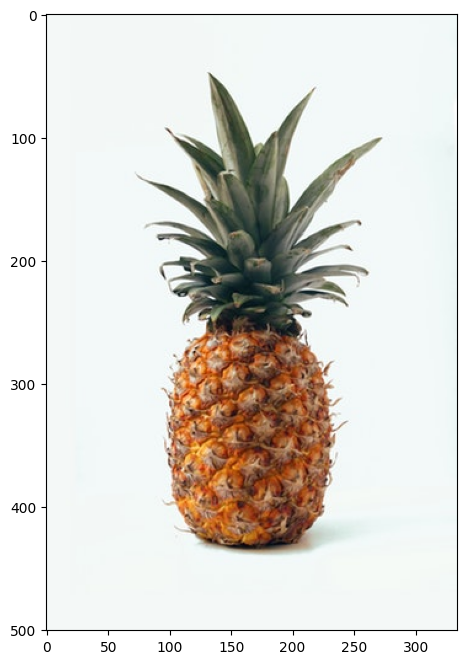

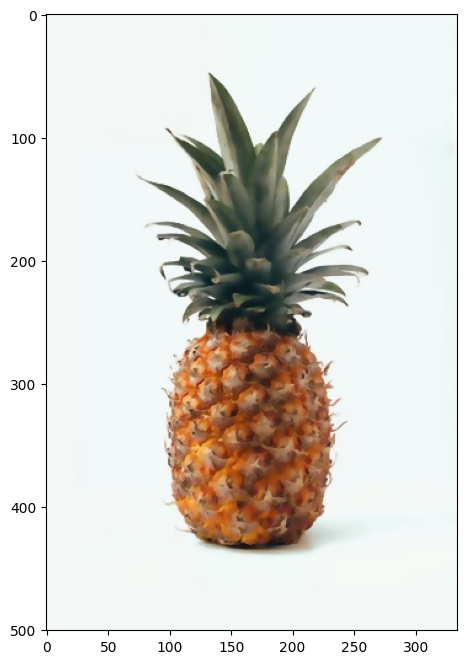

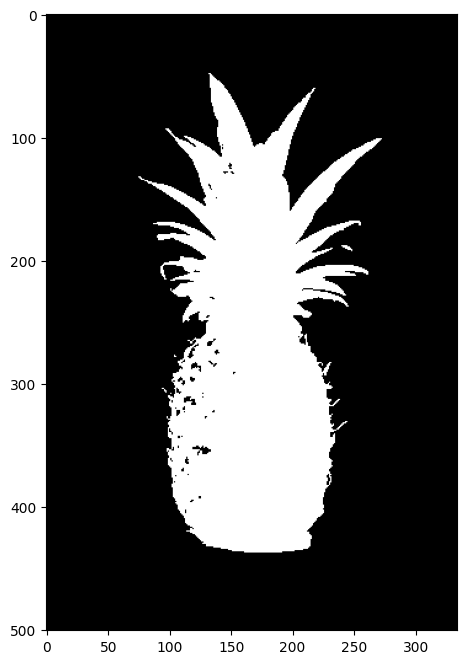

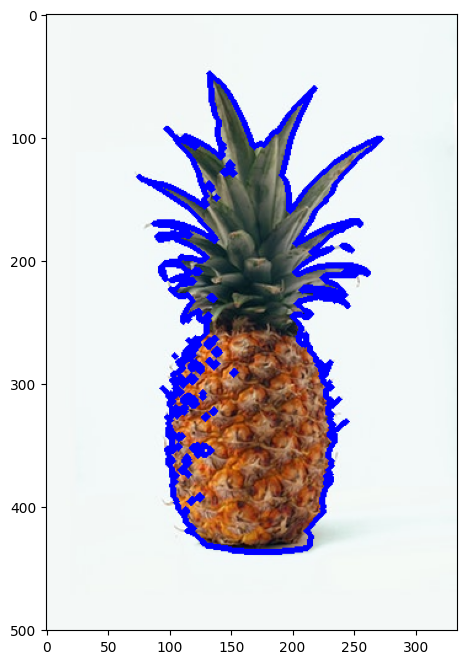

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def display(img, cmap = None):
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap = cmap)

img = cv2.imread('pine_apple.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
display(img)

# Blurring for removing the noise 
img_blur = cv2.bilateralFilter(img, d = 7, 
                               sigmaSpace = 75, sigmaColor =75)
display(img_blur)
#Convert to grayscale 
img_gray = cv2.cvtColor(img_blur, cv2.COLOR_RGB2GRAY)
#Apply the thresholding
a = img_gray.max()  
_, thresh = cv2.threshold(img_gray, a/2+60, a,cv2.THRESH_BINARY_INV)
display(thresh, cmap = 'gray')
#find contours
contours, hierarchy = cv2.findContours(
                                   image = thresh, 
                                   mode = cv2.RETR_TREE, 
                                   method = cv2.CHAIN_APPROX_SIMPLE)
#drawContours
cv2.drawContours(img,contours,-1,(0,0,255),3)
display(img, cmap = 'gray')


dict_keys(['m00', 'm10', 'm01', 'm20', 'm11', 'm02', 'm30', 'm21', 'm12', 'm03', 'mu20', 'mu11', 'mu02', 'mu30', 'mu21', 'mu12', 'mu03', 'nu20', 'nu11', 'nu02', 'nu30', 'nu21', 'nu12', 'nu03'])
1132
(1132, 1, 2)


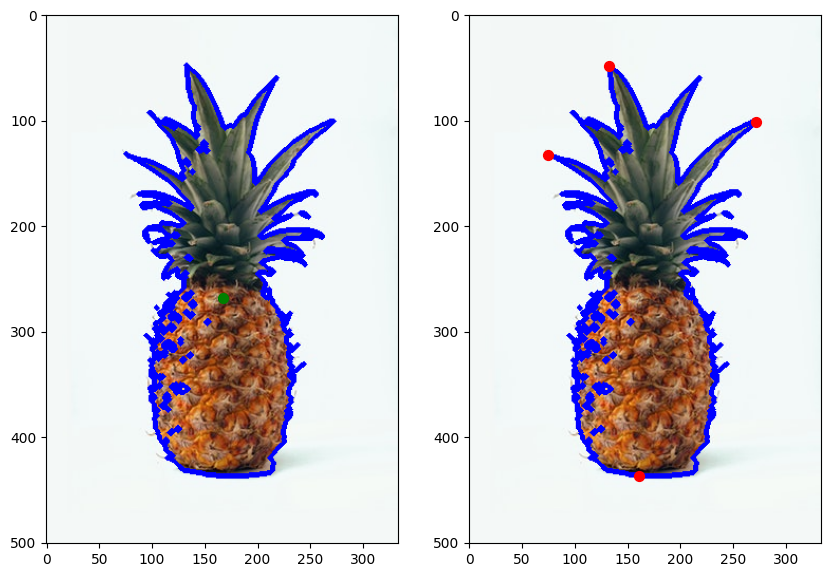

In [44]:
#for i in range(len(contours)):
#    print(str(i) + "th Contour Area : ", cv2.contourArea(contours[i]))
c_4 = contours[4]
M = cv2.moments(c_4)
print(M.keys())
print(len(c_4))

#The centroid point
cx = int(M['m10'] / M['m00'])
cy = int(M['m01'] / M['m00'])

# The extreme points
print(c_4.shape)
l_m = tuple(c_4[c_4[:, :, 0].argmin()][0])
r_m = tuple(c_4[c_4[:, :, 0].argmax()][0])
t_m = tuple(c_4[c_4[:, :, 1].argmin()][0])
b_m = tuple(c_4[c_4[:, :, 1].argmax()][0])
pst = [l_m, r_m, t_m, b_m]
xcor = [p[0] for p in pst]
ycor = [p[1] for p in pst]

plt.figure(figsize = (10, 16))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap = 'gray')
plt.scatter([cx], [cy], c = 'g', s = 50)
plt.subplot(1, 2, 2)
plt.imshow(img, cmap = 'gray') # image
plt.scatter(xcor, ycor, c = 'r', s = 50)


